In [1]:
# Plot super regions mortality with error bars

In [3]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import get_scenario_config

In [2]:
def load_regional_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_stats_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataset(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [11]:
def process_final_decade(ds, var_prefix="M"):
    """
    Build boxplot stats dictionaries for each region using the final 10 years of data.
    Ensemble mean is used, but regions are preserved.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain variables: {prefix}_mean, {prefix}_median, {prefix}_25,
        {prefix}_75, {prefix}_lower95, {prefix}_upper95
        and coordinates 'year', 'ensemble', 'region'.
    var_prefix : str
        Prefix for variable names (default: "M").

    Returns
    -------
    stats_dict : dict
        Keys = region names, values = list with a single boxplot stats dict.
        This structure allows direct use with ax.bxp().
    regions : list
        List of region names (in the same order as stats_dict).
    """

    # collapse ensemble dimension
    ds_mean = ds.mean(dim="ensemble")

    # define final decade
    end_year = int(ds_mean.year.max())
    start_year = end_year - 9
    sub = ds_mean.sel(year=slice(start_year, end_year))

    # build stats for each region
    stats_dict = {}
    for region in sub.region.values:
        reg = sub.sel(region=region)

        stats_dict[region] = [{
            "med": float(reg[f"{var_prefix}_median"].mean()),
            "mean": float(reg[f"{var_prefix}_mean"].mean()),
            "q1": float(reg[f"{var_prefix}_25"].mean()),
            "q3": float(reg[f"{var_prefix}_75"].mean()),
            "whislo": float(reg[f"{var_prefix}_lower95"].mean()),
            "whishi": float(reg[f"{var_prefix}_upper95"].mean()),
            "fliers": []
        }]

    return stats_dict, list(stats_dict.keys())


In [153]:
def plot_regional_mortality(ds, model, scenario, years, zoom=False):
    # === Path config ===
    SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional"

    # Calculate end of scenario mean (10 years)
    end_idx = ds.sizes["year"]
    # Select the last 10 years
    ds_last10 = ds.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = ds_last10.year[0].item()
    end_time = ds_last10.year[-1].item()

    dates = f"{start_time}-{end_time}"

    ds_slice = ds_last10.mean(dim=("ensemble", "year"))

    # Sort by mean values (descending order)
    sorted_idx = np.argsort(ds_slice["M_mean"].values)[::-1]

    da_mean = ds_slice.isel(region=sorted_idx)["M_mean"]
    da_median = ds_slice.isel(region=sorted_idx)["M_median"]
    da_lower = ds_slice.isel(region=sorted_idx)["M_lower95"]
    da_upper = ds_slice.isel(region=sorted_idx)["M_upper95"]

    # Calculate asymmetric error bars
    xerr = np.array([
        da_mean.values - da_lower.values,  # lower error
        da_upper.values - da_mean.values   # upper error
    ])

    # Horizontal point plot with error bars and log x-axis
    plt.figure(figsize=(8, 10))
    plt.errorbar(
        da_mean.values,
        da_mean['region'],
        xerr=xerr,
        fmt='o',                # points
        color='darkblue',
        ecolor='lightgray',     # color of error bars
        lw=1.5,
        capsize=3               # small caps at ends of error bars
    )
    plt.plot(
        da_median.values,
        da_median["region"],
        "^",
        color="lightblue",
        markersize=10,
        label="Median"
    )
    plt.xlabel("Mortality (mean)")
    plt.ylabel("Region")
    plt.title(f"Mortality by Region with 95% CI\n {model} {scenario} {dates}")
    plt.xscale('log')  # Logarithmic x-axis
    if zoom is True:
        plt.xlim(100, 1e6)
        ticks = [100, 1000, 10000, 100000, 1000000]
        plt.gca().set_xticks(ticks, ticks)
        out_file = f"Mortality_region_zoom_{model}_{scenario}_{dates}.png"
    else:
        ticks = [0.001, 0.1, 10, 1000, 100000]
        plt.gca().set_xticks(ticks, ticks)
        out_file = f"Mortality_region_{model}_{scenario}_{dates}.png"
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

    return

In [5]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)
years = config["years"]

ds = load_regional_mortality_ensemble_members(model, scenario, config)

#plot_regional_mortality(ds, model, scenario, years, False)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


In [177]:
def plot_regional_difference_mortality(ds, model, scenario, years, zoom=False):
    # === Path config ===
    SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional"

    # Calculate end of scenario mean (10 years)
    end_idx = ds.sizes["year"]
    # Select the last 10 years
    ds_last10 = ds.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = ds_last10.year[0].item()
    end_time = ds_last10.year[-1].item()

    dates = f"{start_time}-{end_time}"

    ds_slice = ds_last10.mean(dim=("ensemble", "year"))

    # Sort by mean values (descending order)
    sorted_idx = np.argsort(ds_slice["M_mean"].values)[::-1]

    da_mean = ds_slice.isel(region=sorted_idx)["M_mean"]
    da_lower = ds_slice.isel(region=sorted_idx)["M_lower95"]
    da_upper = ds_slice.isel(region=sorted_idx)["M_upper95"]

    # Calculate asymmetric error bars
    xerr = np.array([
        np.abs(da_mean.values - da_lower.values),  # lower error
        np.abs(da_upper.values - da_mean.values)   # upper error
    ])

    # Color bars based on positive/negative
    colors = ["crimson" if val >= 0 else "mediumblue" for val in da_mean.values]

    # Horizontal bar plot with error bars and solid edges
    plt.figure(figsize=(8, 10))
    plt.barh(
        da_mean['region'],
        da_mean.values,
        color=colors,
        edgecolor='black',
        lw=0.5
    )
    plt.errorbar(
        da_mean.values,
        da_mean['region'],
        xerr=xerr,
        fmt='none',       # don't plot points (already in bars)
        ecolor='black',
        elinewidth=0.7,     # thickness of error bars
        capsize=3
    )

    if zoom is True:
        plt.xlim(-500, 500)
        out_file = f"Mortality_region_zoom_{model}_{scenario}_{dates}.png"
    else:
        out_file = f"Mortality_region_{model}_{scenario}_{dates}.png"
    plt.xlabel("Mortality (mean)")
    plt.ylabel("Region")
    plt.title(f"Mortality by Region with 95% CI\n {model} {scenario} ({dates})")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()

    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


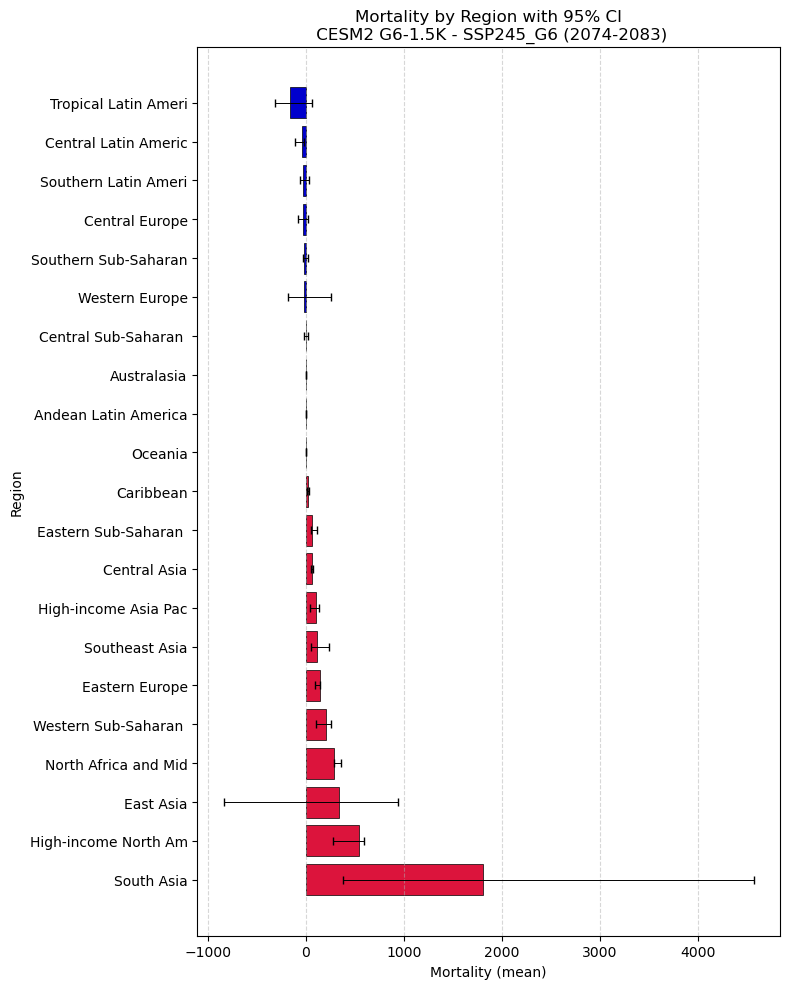

In [178]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"  # Check this is the way round you want it

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1 = load_regional_mortality_ensemble_members(model, scenario[0], config1)
da2 = load_regional_mortality_ensemble_members(model, scenario[1], config2)

da = da1 - da2  # Check this is the way round you want it

plot_regional_difference_mortality(da, model, scenario_name, years, False)